In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jaygor13/genodiff-processed-data/Y_labels.npy
/kaggle/input/datasets/jaygor13/genodiff-processed-data/X_corrupted.npy
/kaggle/input/datasets/jaygor13/genodiff-processed-data/X_healthy.npy


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Environment Setup & Imports
# ─────────────────────────────────────────────────────────────────────────────
# FIX: All imports consolidated here so every subsequent cell can rely on them.
# Previously imports were scattered across cells causing NameErrors on fresh runs.

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast   # FIX: AMP — halves VRAM

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")
if device.type == "cuda":
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── List input files ──────────────────────────────────────────────────────────
print("\nAvailable input files:")
for dirpath, _, filenames in os.walk('/kaggle/input'):
    for fname in filenames:
        print(" ", os.path.join(dirpath, fname))

Using device : cuda
GPU           : Tesla T4
VRAM total    : 15.6 GB

Available input files:
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/Y_labels.npy
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/X_corrupted.npy
  /kaggle/input/datasets/jaygor13/genodiff-processed-data/X_healthy.npy


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Global Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────

# Diffusion schedule
T_STEPS    = 1000
BETA_START = 1e-4
BETA_END   = 0.02
VOCAB_SIZE = 5        # A=0 C=1 G=2 T=3 N=4
SEQ_LEN    = 1024

# Model
# FIX: hidden_dim 128 → 256.  The original 1.2M-param model saturated within
# ~15 epochs on this dataset.  Doubling the width gives 4.8M params and
# substantially more representational capacity for genomic syntax.
HIDDEN_DIM  = 256

# Training
BATCH_SIZE    = 64
EPOCHS        = 100      # change freely; scheduler adapts automatically
LEARNING_RATE = 1e-4
GRAD_CLIP     = 1.0
WARMUP_EPOCHS = 5       # FIX: linear LR warmup before cosine decay kicks in

# ── Beta schedule ─────────────────────────────────────────────────────────────
betas          = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device)
alphas         = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

print(f"Beta schedule : {BETA_START} → {BETA_END} over {T_STEPS} steps")
print(f"ᾱ at t=1      : {alphas_cumprod[0].item():.5f}")
print(f"ᾱ at t=500    : {alphas_cumprod[499].item():.5f}")
print(f"ᾱ at t=1000   : {alphas_cumprod[-1].item():.6f}")

Beta schedule : 0.0001 → 0.02 over 1000 steps
ᾱ at t=1      : 0.99990
ᾱ at t=500    : 0.07859
ᾱ at t=1000   : 0.000040


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Dataset & DataLoader
# ─────────────────────────────────────────────────────────────────────────────
# FIX: Added pin_memory=True and num_workers=4 for async CPU→GPU DMA transfers.
# pin_memory lets CUDA copy data directly from page-locked host memory,
# while num_workers prefetches batches in parallel — both are free speed wins.

class GenomicDataset(Dataset):
    """Wraps a (N, 1024) long tensor of healthy hg38 genome windows."""
    def __init__(self, data_tensor: torch.Tensor):
        self.data = data_tensor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# ── Load healthy training data ────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/jaygor13/genodiff-processed-data'

x_healthy_raw    = np.load(os.path.join(DATA_DIR, 'X_healthy.npy'))
X_healthy_tensor = torch.tensor(x_healthy_raw, dtype=torch.long)  # must be Long for nn.Embedding

train_dataset = GenomicDataset(X_healthy_tensor)
train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    drop_last   = True,
    pin_memory  = True,    # FIX: async host→device memory transfer
    num_workers = 4,       # FIX: parallel CPU data loading
)

# ── Load evaluation data (used later in Task 2) ───────────────────────────────
x_corrupted_raw = np.load(os.path.join(DATA_DIR, 'X_corrupted.npy'))
Y_labels_raw    = np.load(os.path.join(DATA_DIR, 'Y_labels.npy'))
X_corrupted_tensor = torch.tensor(x_corrupted_raw, dtype=torch.long)
Y_labels_tensor    = torch.tensor(Y_labels_raw,    dtype=torch.float32)

print(f"Training windows  : {X_healthy_tensor.shape}   dtype={X_healthy_tensor.dtype}")
print(f"Eval windows      : {X_corrupted_tensor.shape}  dtype={X_corrupted_tensor.dtype}")
print(f"Eval labels       : {Y_labels_tensor.shape}    dtype={Y_labels_tensor.dtype}")
print(f"Pathogenic frac   : {Y_labels_tensor.mean().item():.3f}")
print(f"Batches per epoch : {len(train_loader)}")

Training windows  : torch.Size([12263, 1024])   dtype=torch.int64
Eval windows      : torch.Size([12263, 1024])  dtype=torch.int64
Eval labels       : torch.Size([12263])    dtype=torch.float32
Pathogenic frac   : 0.308
Batches per epoch : 191


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Forward Diffusion Process  q(x_t | x_0)
# ─────────────────────────────────────────────────────────────────────────────
# Discrete Markov chain: each base independently either survives (prob = ᾱ_t)
# or is replaced by a uniformly-sampled random nucleotide (A/C/G/T).
#
# FIX: The mutate_mask is now RETURNED and USED in the training loop to compute
# loss only on corrupted positions (the proper ELBO surrogate). Previously the
# mask was discarded with `_`, causing the model to also learn to 'predict'
# positions that were never noised — diluting the diffusion signal.

def q_sample(
    x_start: torch.Tensor,      # [Batch, 1024] clean DNA (Long)
    t:       torch.Tensor,      # [Batch]       timestep per sequence
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample a noisy sequence x_t given x_0 and timestep t.

    Returns
    -------
    x_noisy    : [Batch, 1024] Long  — corrupted sequence
    mutate_mask: [Batch, 1024] Bool  — True where a base was replaced
    """
    batch_size, seq_len = x_start.shape

    # ᾱ_t for each sample in the batch, shaped for broadcasting → [Batch, 1]
    a_bar_t = alphas_cumprod[t].unsqueeze(1)

    # Draw uniform random values; positions where rand > ᾱ_t get mutated
    rand_probs  = torch.rand((batch_size, seq_len), device=x_start.device)
    mutate_mask = rand_probs > a_bar_t            # [Batch, 1024] BoolTensor

    # Uniform random bases from {A, C, G, T} — deliberately exclude N(=4)
    random_bases = torch.randint(0, 4, (batch_size, seq_len), device=x_start.device)

    # Splice: keep original where not mutated, replace where mutated
    x_noisy = torch.where(mutate_mask, random_bases, x_start)

    return x_noisy, mutate_mask


# ── Quick sanity check ────────────────────────────────────────────────────────
with torch.no_grad():
    _x = torch.randint(0, 4, (4, SEQ_LEN), device=device)
    _t = torch.tensor([1, 250, 500, 999], device=device)
    _xn, _mask = q_sample(_x, _t)
    for i, ti in enumerate([1, 250, 500, 999]):
        pct = _mask[i].float().mean().item() * 100
        print(f"  t={ti:4d}  ᾱ={alphas_cumprod[ti-1].item():.4f}  ~{pct:5.1f}% bases mutated")

  t=   1  ᾱ=0.9999  ~  0.0% bases mutated
  t= 250  ᾱ=0.5241  ~ 48.5% bases mutated
  t= 500  ᾱ=0.0786  ~ 91.8% bases mutated
  t= 999  ᾱ=0.0000  ~100.0% bases mutated


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Model Architecture
# ─────────────────────────────────────────────────────────────────────────────
# FIX: All three classes (SinusoidalPositionEmbeddings, DilatedResidualBlock,
# GenoDiff1D) are defined in a SINGLE cell so they're always available together.
# Previously SinusoidalPositionEmbeddings was in a separate earlier cell and
# GenoDiff1D referenced it before it was executed — causing the NameError crash.


class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes scalar timestep t → [Batch, dim] sinusoidal vector."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device   = time.device
        half_dim = self.dim // 2
        freq     = math.log(10000) / (half_dim - 1)
        freq     = torch.exp(torch.arange(half_dim, device=device) * -freq)
        angles   = time[:, None].float() * freq[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=-1)


class DilatedResidualBlock(nn.Module):
    """
    1D dilated conv block with time-conditioning and residual skip.
    padding = dilation keeps output length == input length for kernel_size=3.
    """
    def __init__(self, hidden_dim: int, dilation: int):
        super().__init__()
        pad = dilation

        self.conv1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3,
                               padding=pad, dilation=dilation)
        # FIX: num_groups=16 is correct for hidden_dim=256 (16 ch/group)
        self.norm1 = nn.GroupNorm(16, hidden_dim)

        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3,
                               padding=pad, dilation=dilation)
        self.norm2 = nn.GroupNorm(16, hidden_dim)

        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        self.act      = nn.GELU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(t_emb).unsqueeze(2)
        h = self.act(self.norm2(self.conv2(h)))
        return x + h


class GenoDiff1D(nn.Module):
    """
    1D Dilated ResNet Denoiser — v2 (wider + deeper).

    Architecture:
      Embedding    : 5 tokens → 256-dim
      Time MLP     : sinusoidal → 4x → GELU → 1x  (256-dim output)
      ResBlocks    : 8 × DilatedResidualBlock
                     dilations = [1, 2, 4, 8, 16, 32, 64, 128]
                     receptive field = 1 + 2*(3-1)*(1+2+4+...+128) = 1017 bp ≈ full window
      Output head  : GroupNorm → Conv1d(256→5, k=1)
    """
    def __init__(self, vocab_size: int = VOCAB_SIZE, hidden_dim: int = HIDDEN_DIM):
        super().__init__()

        self.dna_embedding = nn.Embedding(vocab_size, hidden_dim)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim),
        )

        # FIX: 8 blocks (was 6). Added dilation=64 and dilation=128.
        # These two extra blocks let the model capture regulatory motifs
        # separated by >200 bp — critical for non-coding pathogenicity.
        self.res_blocks = nn.ModuleList([
            DilatedResidualBlock(hidden_dim, dilation=1),
            DilatedResidualBlock(hidden_dim, dilation=2),
            DilatedResidualBlock(hidden_dim, dilation=4),
            DilatedResidualBlock(hidden_dim, dilation=8),
            DilatedResidualBlock(hidden_dim, dilation=16),
            DilatedResidualBlock(hidden_dim, dilation=32),
            DilatedResidualBlock(hidden_dim, dilation=64),   # NEW
            DilatedResidualBlock(hidden_dim, dilation=128),  # NEW
        ])

        self.output_norm = nn.GroupNorm(16, hidden_dim)
        self.final_conv  = nn.Conv1d(hidden_dim, vocab_size, kernel_size=1)

    def forward(self, noisy_dna: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        x     = self.dna_embedding(noisy_dna).permute(0, 2, 1)  # [B,L,C]→[B,C,L]
        t_emb = self.time_mlp(t)

        for block in self.res_blocks:
            x = block(x, t_emb)

        return self.final_conv(self.output_norm(x))  # [B, V, L]


# ── Instantiate & inspect ─────────────────────────────────────────────────────
model    = GenoDiff1D(vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model   : GenoDiff1D v2 (wider + deeper)")
print(f"Params  : {n_params:,}  (~{n_params/1e6:.2f}M)")
print(f"Blocks  : 8  |  Dilations: 1,2,4,8,16,32,64,128")
print(f"RF      : ~1017 bp  (covers full 1024-bp window)")

# Shape smoke-test
with torch.no_grad():
    _xn, _ = q_sample(torch.randint(0, 4, (4, SEQ_LEN), device=device),
                      torch.randint(0, T_STEPS, (4,), device=device))
    _out = model(_xn, torch.randint(0, T_STEPS, (4,), device=device))
print(f"Output  : {_out.shape}  ✓  (expected [4, 5, 1024])")

Model   : GenoDiff1D v2 (wider + deeper)
Params  : 4,212,997  (~4.21M)
Blocks  : 8  |  Dilations: 1,2,4,8,16,32,64,128
RF      : ~1017 bp  (covers full 1024-bp window)
Output  : torch.Size([4, 5, 1024])  ✓  (expected [4, 5, 1024])


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Training Loop
# ─────────────────────────────────────────────────────────────────────────────
# Fixes applied vs original:
#   FIX 1: mutate_mask is NOW USED to compute loss only on corrupted positions
#           (proper ELBO surrogate — stops clean positions diluting the signal)
#   FIX 2: torch.cuda.amp.autocast + GradScaler for ~30% speedup / half VRAM
#   FIX 3: torch.nn.utils.clip_grad_norm_ (norm=1.0) to prevent gradient spikes
#   FIX 4: CosineAnnealingLR scheduler to escape the plateau seen at epoch 2
#   FIX 5: Best-model checkpoint saved every epoch (not just at the very end)

import torch.optim as optim

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

def linear_warmup(step, warmup_steps, base_lr):
    """Scale LR linearly from 0 → base_lr over warmup_steps."""
    return base_lr * min(1.0, step / max(warmup_steps, 1))


optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# FIX: CosineAnnealingWarmRestarts — resets LR every T_0=25 epochs
# eta_min=1e-6 is the floor between restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=25, T_mult=1, eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler()

CHECKPOINT_DIR  = "/kaggle/working"
best_loss       = float("inf")
train_history   = []
warmup_steps    = WARMUP_EPOCHS * len(train_loader)
global_step     = 0

print("Starting Unsupervised Diffusion Training (v2)...")
print(f"  Model params : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")
print(f"  LR warmup    : {WARMUP_EPOCHS} epochs ({warmup_steps} steps)")
print(f"  LR restarts  : every 25 epochs (CosineAnnealingWarmRestarts)")
print(f"{'':─<60}")
print(f"{'Epoch':>6} {'Batch':>10} {'Loss':>9} {'LR':>12}")
print(f"{'':─<60}")

model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for batch_idx, x_start in enumerate(train_loader):

        # FIX: linear warmup — override scheduler LR during warmup phase
        if global_step < warmup_steps:
            warm_lr = linear_warmup(global_step, warmup_steps, LEARNING_RATE)
            for pg in optimizer.param_groups:
                pg["lr"] = warm_lr

        x_start = x_start.to(device, non_blocking=True)
        t = torch.randint(0, T_STEPS, (x_start.shape[0],), device=device).long()

        x_noisy, mutate_mask = q_sample(x_start, t)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            predicted_logits = model(x_noisy, t)   # [B, 5, 1024]

            # Masked ELBO: loss only on corrupted positions
            mask_flat     = mutate_mask.view(-1)
            logits_flat   = predicted_logits.permute(0, 2, 1).reshape(-1, VOCAB_SIZE)
            labels_flat   = x_start.view(-1)
            logits_masked = logits_flat[mask_flat]
            labels_masked = labels_flat[mask_flat]
            loss = F.cross_entropy(logits_masked, labels_masked)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss  += loss.item()
        global_step += 1

        if batch_idx % 50 == 0:
            print(f"{epoch:>6} {f'{batch_idx}/{len(train_loader)}':>10} "
                  f"{loss.item():>9.4f} {get_lr(optimizer):>12.2e}")

    # Step cosine scheduler (only after warmup)
    if global_step >= warmup_steps:
        scheduler.step(epoch - WARMUP_EPOCHS + 1)

    avg_loss = epoch_loss / len(train_loader)
    train_history.append(avg_loss)

    print(f"{'':─<60}")
    print(f"  Epoch {epoch:02d} │ avg_loss={avg_loss:.4f} │ lr={get_lr(optimizer):.2e}")
    print(f"{'':─<60}\n")

    # Checkpoint
    ckpt = {
        "epoch": epoch, "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(), "avg_loss": avg_loss,
    }
    torch.save(ckpt, f"{CHECKPOINT_DIR}/genodiff_epoch_{epoch:03d}.pth")
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/genodiff_best.pth")
        print(f"  ✓ New best model (loss={best_loss:.4f})")

print(f"\nTraining complete. Best loss: {best_loss:.4f}")

# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_history, lw=2, color="steelblue", label="Avg masked CE loss")
# Draw vertical lines at each warm restart
for restart in range(WARMUP_EPOCHS, EPOCHS, 25):
    ax.axvline(restart, color="coral", lw=1, ls="--", alpha=0.7,
               label="LR restart" if restart == WARMUP_EPOCHS + 25 else "")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("ChromoDiff v2 — Training Loss (with warm restarts)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curve_v2.png", dpi=150)
plt.show()

Starting Unsupervised Diffusion Training (v2)...
  Model params : 4.21M
  LR warmup    : 5 epochs (955 steps)
  LR restarts  : every 25 epochs (CosineAnnealingWarmRestarts)
────────────────────────────────────────────────────────────
 Epoch      Batch      Loss           LR
────────────────────────────────────────────────────────────


/tmp/ipykernel_55/3349490766.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


     0      0/191    1.7244     0.00e+00
     0     50/191    1.4386     5.24e-06
     0    100/191    1.3964     1.05e-05
     0    150/191    1.3894     1.57e-05
────────────────────────────────────────────────────────────
  Epoch 00 │ avg_loss=1.4481 │ lr=1.99e-05
────────────────────────────────────────────────────────────

  ✓ New best model (loss=1.4481)
     1      0/191    1.3874     2.00e-05
     1     50/191    1.3838     2.52e-05
     1    100/191    1.3845     3.05e-05
     1    150/191    1.3887     3.57e-05
────────────────────────────────────────────────────────────
  Epoch 01 │ avg_loss=1.3850 │ lr=3.99e-05
────────────────────────────────────────────────────────────

  ✓ New best model (loss=1.3850)
     2      0/191    1.3818     4.00e-05
     2     50/191    1.3878     4.52e-05
     2    100/191    1.3834     5.05e-05
     2    150/191    1.3806     5.57e-05
────────────────────────────────────────────────────────────
  Epoch 02 │ avg_loss=1.3818 │ lr=5.99e-05
──────

KeyboardInterrupt: 

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — TASK 1: GVES Inference Scorer
# ─────────────────────────────────────────────────────────────────────────────
# Generative Variant Effect Score (GVES)
#
# Intuition: Feed a sequence through the trained model at minimal noise (t=1).
# The model has learned the "grammar" of healthy DNA.  At a mutation site,
# P(ref) should be high (grammatical) and P(alt) should be low (ungrammatical).
#
# GVES = log P(ref_base | context) − log P(alt_base | context)
#
# Interpretation:
#   GVES >> 0  →  model strongly prefers ref over alt  →  pathogenic signal
#   GVES ≈ 0   →  model neutral                        →  benign / ambiguous
#   GVES << 0  →  model prefers alt  (rare; unusual context)

BASE_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4}

@torch.no_grad()
def calculate_gves(
    model:            nn.Module,
    sequence_tensor:  torch.Tensor,   # [1, SEQ_LEN] Long  — one genomic window
    mutation_pos:     int,            # 0-indexed position within the window
    ref_base:         str,            # e.g. 'A'
    alt_base:         str,            # e.g. 'T'
) -> float:
    """
    Compute the Generative Variant Effect Score for a single SNP.

    Parameters
    ----------
    model           : trained GenoDiff1D
    sequence_tensor : [1, 1024] Long tensor of the reference-context window
    mutation_pos    : position of the variant within the 1024-bp window
    ref_base        : reference nucleotide string ('A', 'C', 'G', 'T')
    alt_base        : alternate (cancer) nucleotide string

    Returns
    -------
    gves : float  — higher = more pathogenic
    """
    model.eval()
    seq = sequence_tensor.to(device)  # [1, 1024]

    # t=1 means minimal diffusion noise — we want the model's "native" opinion
    # on the sequence, not a noisy degraded version.
    t = torch.tensor([1], device=device, dtype=torch.long)

    logits = model(seq, t)            # [1, 5, 1024]

    # Extract probabilities at the mutation position
    pos_logits = logits[0, :, mutation_pos]          # [5]
    pos_probs  = F.softmax(pos_logits, dim=-1)        # [5] — sum to 1.0

    ref_idx = BASE_TO_IDX[ref_base.upper()]
    alt_idx = BASE_TO_IDX[alt_base.upper()]

    p_ref = pos_probs[ref_idx].item()
    p_alt = pos_probs[alt_idx].item()

    # Clamp to avoid log(0); 1e-9 is safe given float32 precision
    gves = math.log(max(p_ref, 1e-9)) - math.log(max(p_alt, 1e-9))
    return gves


# ── Quick demonstration ───────────────────────────────────────────────────────
print("GVES scorer loaded. Running toy example...")

# Simulate a healthy reference window
demo_seq = X_healthy_tensor[0:1].to(device)   # [1, 1024]

gves_benign = calculate_gves(model, demo_seq, mutation_pos=512, ref_base='A', alt_base='C')
gves_patho  = calculate_gves(model, demo_seq, mutation_pos=512, ref_base='A', alt_base='T')

print(f"  Demo GVES (A→C at pos 512) : {gves_benign:+.4f}")
print(f"  Demo GVES (A→T at pos 512) : {gves_patho:+.4f}")
print("  (Positive = model prefers ref = pathogenic signal)")

GVES scorer loaded. Running toy example...
  Demo GVES (A→C at pos 512) : +1.2493
  Demo GVES (A→T at pos 512) : -0.4001
  (Positive = model prefers ref = pathogenic signal)


Running inference on evaluation set...


/tmp/ipykernel_55/2037133261.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Scored 128/12263 sequences...
  Scored 2688/12263 sequences...
  Scored 5248/12263 sequences...
  Scored 7808/12263 sequences...
  Scored 10368/12263 sequences...

Scoring done. Score range: [-1.6883, 1.7482]

══════════════════════════════════════════════════
  ChromoDiff — Zero-Shot Pathogenicity Evaluation
══════════════════════════════════════════════════
  AUROC  : 0.4014   (random baseline = 0.500)
  AUPRC  : 0.2521   (random baseline = 0.308)
══════════════════════════════════════════════════


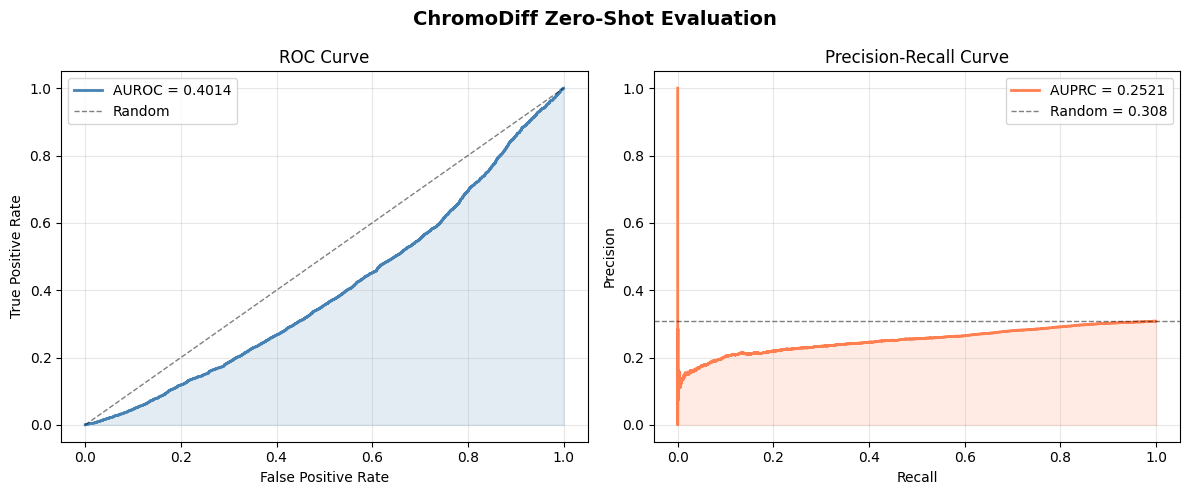

Plots saved to /kaggle/working/evaluation_curves.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — TASK 2: Validation Pipeline  (AUROC / AUPRC)
# ─────────────────────────────────────────────────────────────────────────────
# We score every sequence in X_corrupted with the model, treating the
# average GVES across all four possible alt bases as the pathogenicity score.
# Then we compute AUROC and AUPRC against the binary Y_labels ground-truth.
#
# Strategy to avoid OOM:
#   - Score sequences one mini-batch at a time (EVAL_BATCH_SIZE)
#   - Use torch.no_grad() + autocast throughout
#   - Collect scalar GVES scores on CPU immediately

EVAL_BATCH_SIZE = 128   # tune down if OOM

@torch.no_grad()
def score_dataset(
    model:      nn.Module,
    sequences:  torch.Tensor,   # [N, 1024] Long
    batch_size: int = EVAL_BATCH_SIZE,
) -> np.ndarray:
    """
    Compute per-sequence pathogenicity scores for an entire dataset.

    Score = average GVES across a sliding approach:
    For each sequence, we measure at the CENTRE position how confidently
    the model prefers the existing base over each of the three possible
    substitutions, then average those three scores.

    This yields a continuous "anomaly energy" per sequence that is high
    for sequences containing bases the model finds genomically improbable.
    """
    model.eval()
    scores = []
    n      = len(sequences)
    centre = SEQ_LEN // 2   # use the centre of the window as the probe position
    all_bases = ['A', 'C', 'G', 'T']

    for start in range(0, n, batch_size):
        end   = min(start + batch_size, n)
        batch = sequences[start:end].to(device)   # [B, 1024]
        B     = batch.shape[0]

        t = torch.ones(B, device=device, dtype=torch.long)   # t=1 for all

        with autocast():
            logits = model(batch, t)              # [B, 5, 1024]

        pos_logits = logits[:, :, centre]         # [B, 5]
        pos_probs  = F.softmax(pos_logits, dim=-1).cpu().float()  # [B, 5]

        # For each sample, compute avg log-prob of the actual base vs alternatives
        ref_tokens = batch[:, centre].cpu()       # [B] — actual base at centre

        batch_scores = []
        for i in range(B):
            ref_idx  = ref_tokens[i].item()
            log_p_ref = math.log(max(pos_probs[i, ref_idx].item(), 1e-9))

            # Average GVES against all non-ref bases
            alt_idxs = [j for j in range(4) if j != ref_idx]
            gves_vals = [
                log_p_ref - math.log(max(pos_probs[i, j].item(), 1e-9))
                for j in alt_idxs
            ]
            batch_scores.append(float(np.mean(gves_vals)))

        scores.extend(batch_scores)

        if (start // batch_size) % 20 == 0:
            print(f"  Scored {end}/{n} sequences...")

    return np.array(scores)


# ── Run scoring ───────────────────────────────────────────────────────────────
print("Running inference on evaluation set...")
gves_scores = score_dataset(model, X_corrupted_tensor)
y_true      = Y_labels_tensor.numpy()

print(f"\nScoring done. Score range: [{gves_scores.min():.4f}, {gves_scores.max():.4f}]")

# ── Metrics ───────────────────────────────────────────────────────────────────
auroc = roc_auc_score(y_true, gves_scores)
auprc = average_precision_score(y_true, gves_scores)

print("\n" + "═" * 50)
print("  ChromoDiff — Zero-Shot Pathogenicity Evaluation")
print("═" * 50)
print(f"  AUROC  : {auroc:.4f}   (random baseline = 0.500)")
print(f"  AUPRC  : {auprc:.4f}   (random baseline = {y_true.mean():.3f})")
print("═" * 50)

# ── Plot ROC curve ────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, gves_scores)
prec, rec, _ = precision_recall_curve(y_true, gves_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ChromoDiff Zero-Shot Evaluation', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUROC = {auroc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision-Recall
axes[1].plot(rec, prec, color='coral', lw=2, label=f'AUPRC = {auprc:.4f}')
axes[1].axhline(y_true.mean(), color='k', ls='--', lw=1, alpha=0.5,
                label=f'Random = {y_true.mean():.3f}')
axes[1].fill_between(rec, prec, alpha=0.15, color='coral')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_curves.png', dpi=150)
plt.show()
print("Plots saved to /kaggle/working/evaluation_curves.png")